This is a notebook to generate the local persistance length over a window of size 10nm and which is rolled over the entire coiled-coil protein imaged through HS-AFM imaging.


It is representated a time average for all the frames over all videos.

In [1]:
#importing all the required modules 
from scipy import stats
import warnings
from class_mech_gui import Filament_mech_gui
import seaborn as sns
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils import find_folder_name,df_fil1_fil_2_all_L_p_s,do_LP_colred_SEM
import warnings
warnings.filterwarnings("ignore")


In [2]:
#initializing the class and loading the data

window_size = 10.0 # in nm
window_size_MSD = 0.50 # in percent of normalized arc length

folder_path_arr = ['S/1/']
f_label_arr = [find_folder_name(os.path.dirname(
    f))+"_"+find_folder_name(f) for f in folder_path_arr]

In [ ]:
# Calculating the local Lp of 
df_lp = pd.DataFrame()
df_all_1_2 = pd.DataFrame()
for i in range(len(folder_path_arr)):
    ex = Filament_mech_gui(folder_path_arr[i], f_label_arr[i], num_segs=9)
    ex.roll_win_L_p_1_per_1rgn_cont(del_arc_l_nm=window_size)
    ex.L_p_plot_poster(0.2, ax, j, del_arc_l_nm=10)

    df_temp = ex.df_output
    df_temp['config_label'] = f_label_arr[i][0]

    df_temp_12, swap_bool = df_fil1_fil_2_all_L_p_s(df_temp)
    if swap_bool:
        print(f_label_arr[i])

        df_temp['swapped_arc_len'] = df_temp['avg_arc_l_win_fil_2'] - 0.01
        df_temp['swapped_arc_len_nm'] = df_temp['max_arc_l'] * \
            (df_temp['avg_arc_l_win_fil_2'] - 0.01)

    else:
        df_temp['swapped_arc_len'] = df_temp['avg_arc_l_win_fil_1']
        df_temp['swapped_arc_len_nm'] = df_temp['max_arc_l'] * \
            df_temp['avg_arc_l_win_fil_1']

    df_lp = pd.concat([df_lp, df_temp])
df_lp = df_lp.round({'swapped_arc_len': 2, 'avg_arc_l_win_fil_1': 2})

(-4.0, 135.0)

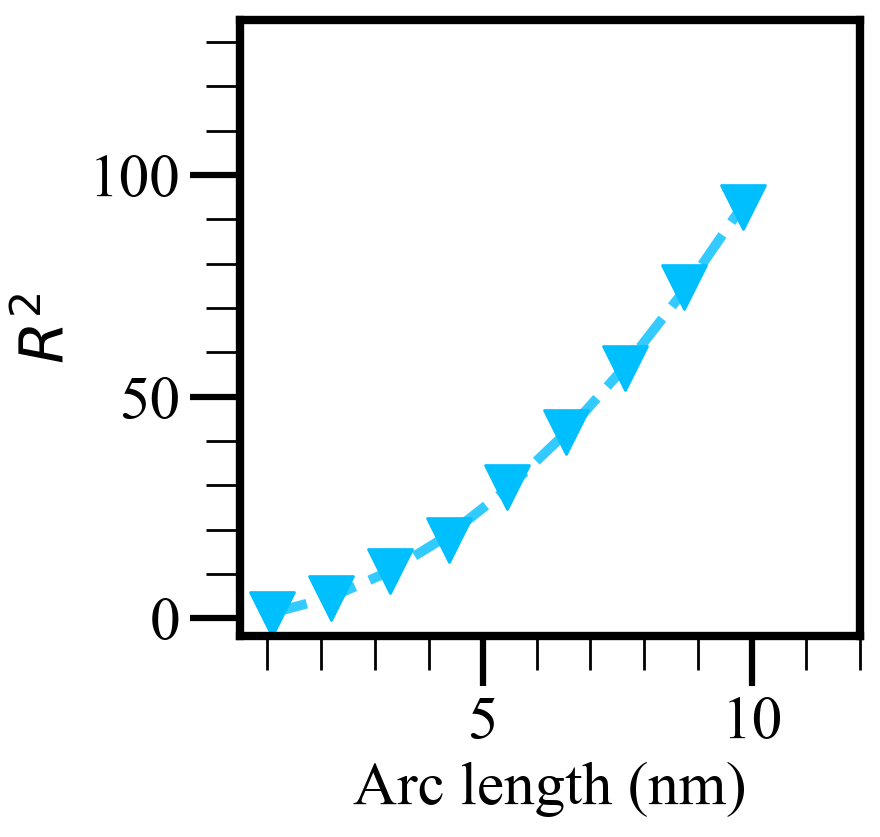

In [24]:
#representative WLC fitting for the local L_p 

plt.figure(figsize=(4, 4), dpi=200)
ax = plt.gca()
ex = Filament_mech_gui(folder_path_arr[0], f_label_arr[0], num_segs=9)
ex.L_p_plot_poster(0.2, ax, 0, del_arc_l_nm=window_size) 
ax.set_xlabel('Arc length (nm)')
ax.set_ylabel('$R^2$')
plt.xlim(0.5, 12)
plt.ylim(-4, 135)


In [ ]:
for name, df_config in df_lp.groupby(['config_label']):
    plt.figure()
    ax = plt.gca()
    norm_s_name = 'avg_arc_l_win_fil_1'
    file_label = df_config['file_label'].to_numpy()[0]

    plt.rcParams['figure.figsize'] = [13.206, 8.791]

    plt_dict = {'font.size': 42.016808, 'lines.markersize': 14, 'figure.dpi': 300, 'lines.color': 'black',
                'xtick.major.size': 18, 'ytick.major.size': 18, 'xtick.minor.size': 12.15050424, 'ytick.minor.size': 12.15050424,
                'font.family': 'Times New Roman', 'axes.linewidth': 3,
                'xtick.major.width': 2.25, 'ytick.major.width': 2.25, 'xtick.minor.width': 1, 'ytick.minor.width': 1, 'xtick.minor.visible': True}
    do_LP_colred_SEM(df_config, norm_s_name,
                     bool_file_by_file=False, name=name, ax_passed=ax, plt_dict=plt_dict)
    ax.set_xlabel("Normalised Arc Length", fontsize=plt_dict['font.size'])
    ax.set_ylabel("Local L_p", fontsize=plt_dict['font.size'])
    ax.set_title(file_label, fontsize=plt_dict['font.size'])

The following blocks, we will cimputer the MSD of the end to end distance for a given video of a configuration over elapsed time 

In [3]:
df_MSD_all = pd.DataFrame()
for i in range(len(folder_path_arr)):
    ex = Filament_mech_gui(folder_path_arr[i], f_label_arr[i])
    df_msd, _, _ = ex.R_TAN_BEND_MSD(window_size_MSD)
    df_MSD_all = pd.concat([df_MSD_all, df_msd])


rc in loop :4.273750971271825,4.273750971271825
rc in loop :21.22892998531611,21.22892998531611


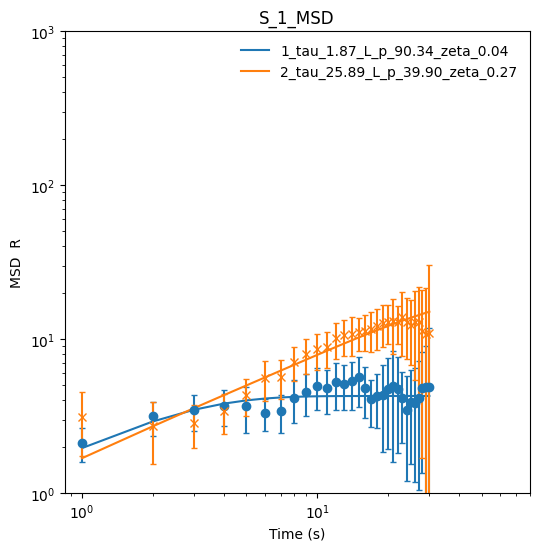

In [4]:

from constants import fit_l_p_header

from utils import fit_func_delta_L
from utils import renormalize_msd
df_group_2 = df_MSD_all.groupby(by='file_label')
df_fit_2 = pd.DataFrame(columns=fit_l_p_header)


for name, group in df_group_2:
    df_temp = group
    bool_m = False
    df_fit_2 = pd.concat([df_fit_2, fit_func_delta_L(df_temp, monomer_bool=bool_m)], ignore_index=True)
df_renorm_MSD = renormalize_msd(df_MSD_all,df_fit_2)

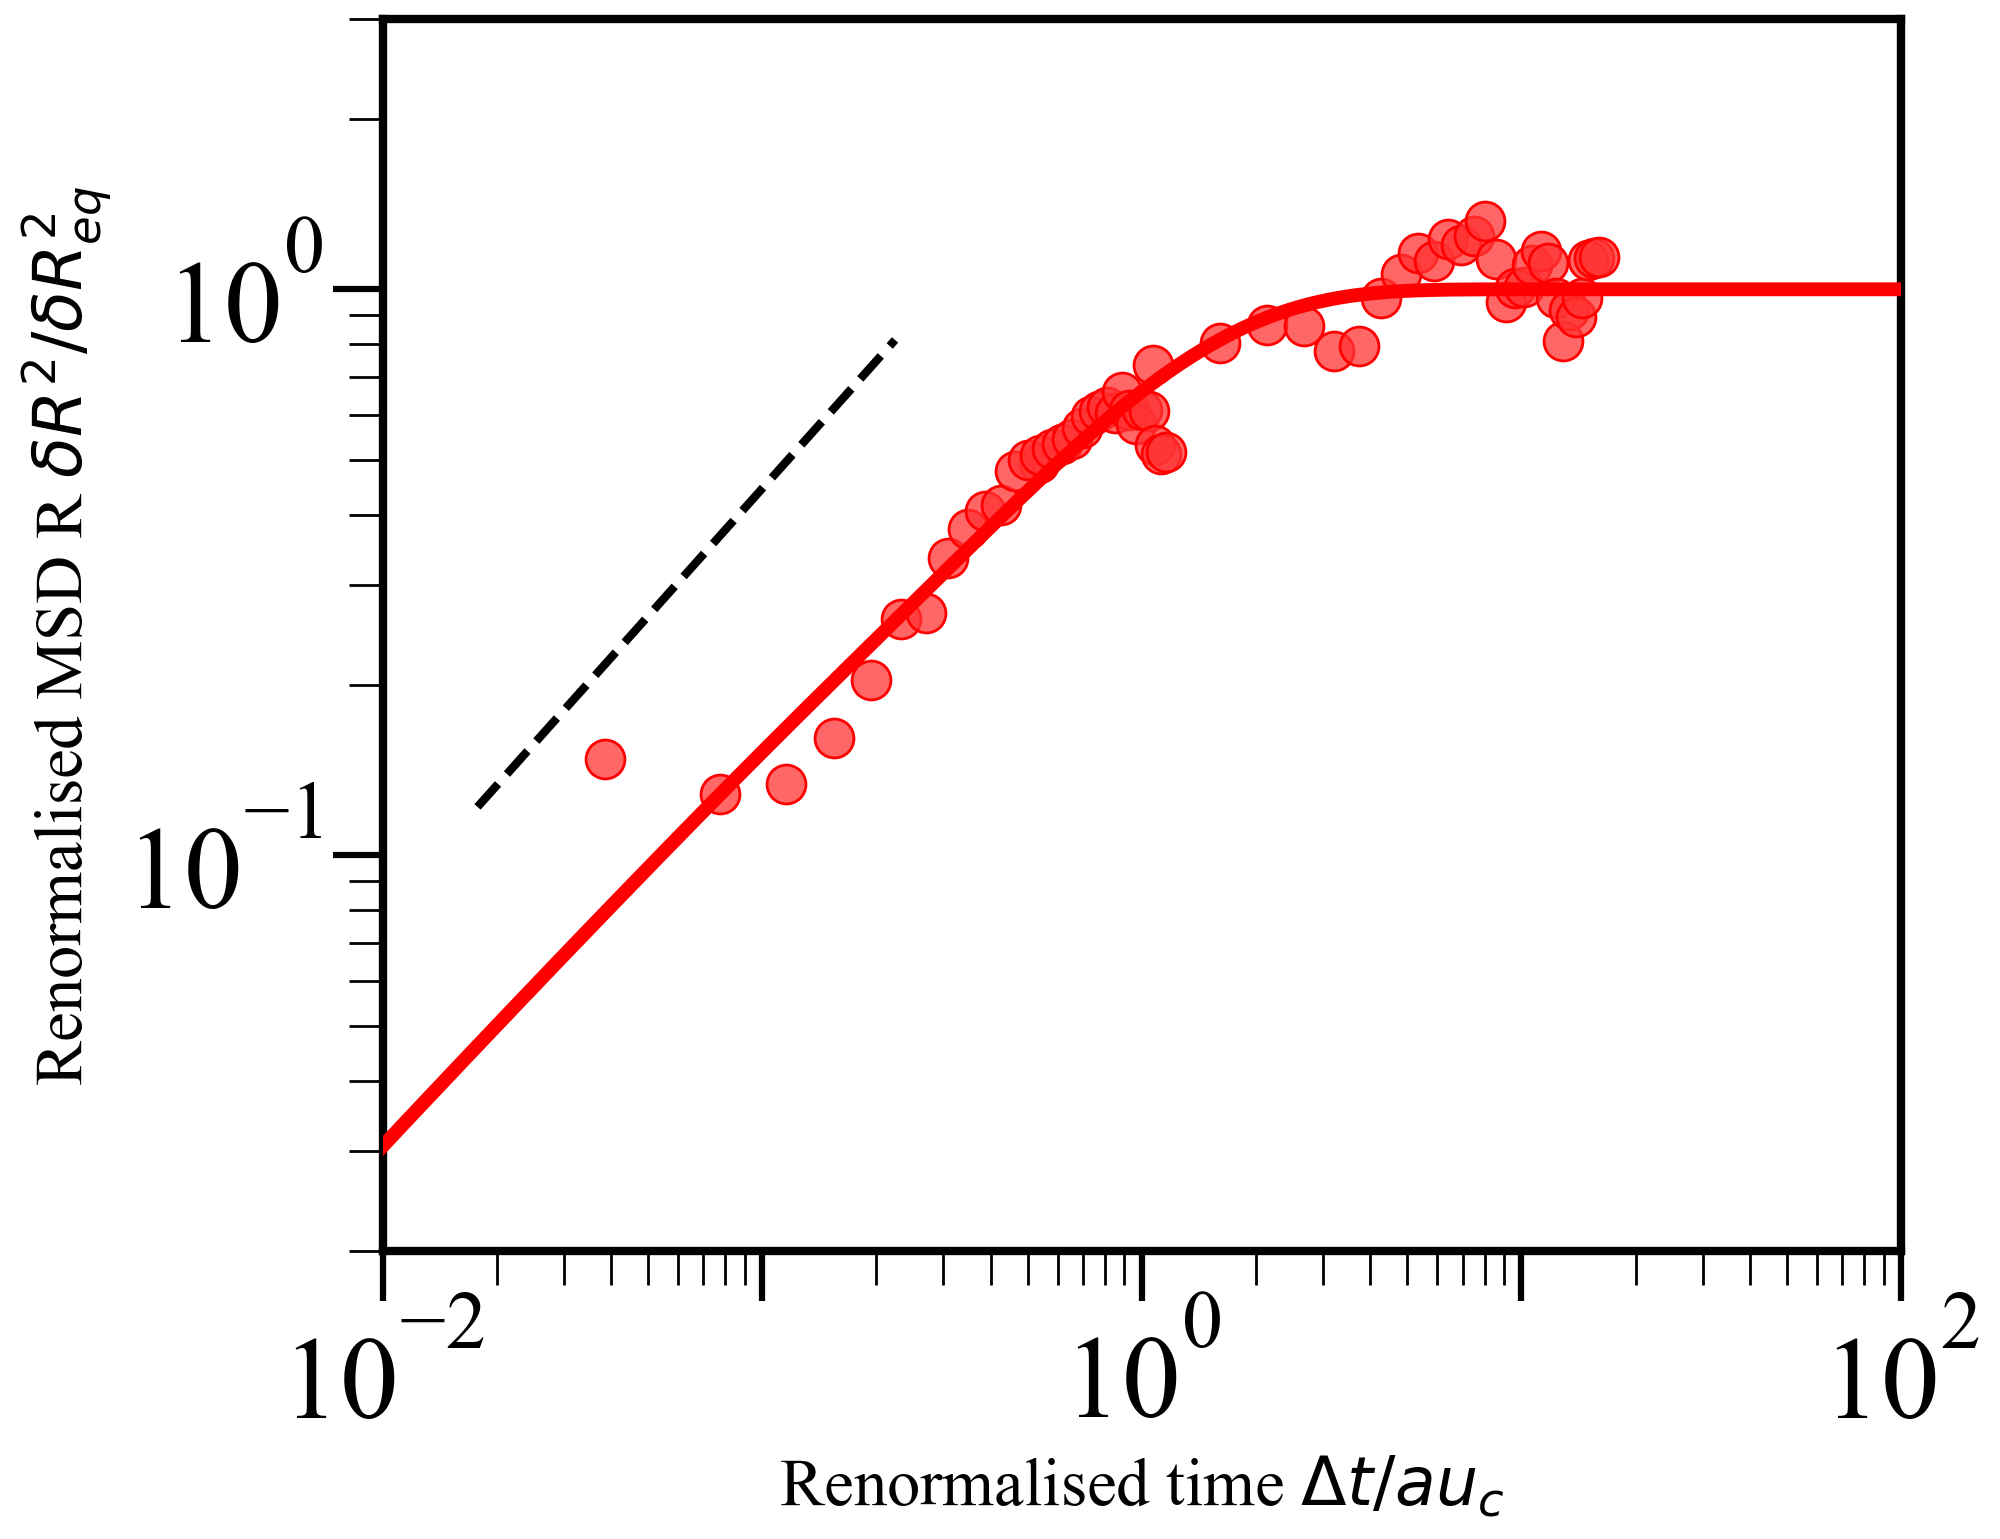

In [16]:
# %%%REscaled MSD
import numpy as np 
from statistics import geometric_mean
from utils import delta_R,generate_lightness_and_transparency_variations
from constants import k_bT_nm,color_saha_configs_hex
from matplotlib.ticker import LogLocator
plt.rcParams['figure.figsize'] = [9.796, 7.998]
plt.rcParams.update({'font.size': 22.016808, 'lines.markersize': 14, 'figure.dpi': 200, 'lines.color': 'black',
                     'xtick.major.size': 18, 'ytick.major.size': 18, 'xtick.minor.size': 12.15050424, 'ytick.minor.size': 12.15050424,
                     'font.family': 'Times New Roman', 'axes.linewidth': 3, "xtick.minor.visible": True, "ytick.minor.visible": True, 'xtick.major.width': 2.25,
                     'ytick.major.width': 2.25, 'xtick.minor.width': 1, 'ytick.minor.width': 1})


# new human data
x_renorm_limits = [0.001, 90000.0]

y_renorm_limit = [0.008, 2.9694807353946584]

off_ref_msd = 2.5
x_ticks = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]


x_tick_labels = [
    '',
    '$\\mathdefault{10^{-2}}$',
    '',
    '$\\mathdefault{10^{0}}$',
    '',
    '$\\mathdefault{10^{2}}$',
    '',
    '$\\mathdefault{10^{4}}$',
    '']

x_renorm_limits = [0.01, 100]
y_renorm_limit = [0.02, 3]

off_ref_msd = 2.5
x_ticks = [0.01, 0.1, 1, 10, 100]


x_tick_labels = [
    '$\\mathdefault{10^{-2}}$',
    '',
    '$\\mathdefault{10^{0}}$',
    '',
    '$\\mathdefault{10^{2}}$'
]
X_unnrom = np.logspace(-5.0, 8, num=1000)


for name, df_config in df_renorm_MSD.groupby(['config_label']):
    plt.figure()
    # Compute the min MSD for each file_label
    min_MSDs = df_config.groupby('file_label')['MSD'].min()

    # Sort labels by increasing MSD (lightest first)
    sorted_labels = min_MSDs.sort_values().index

    L_avg_fit = geometric_mean(df_config['L_fitted'].to_numpy())
    L_p_avg_fit = geometric_mean(df_config['L_p_fitted'].to_numpy())
    zeta_avg_fit = geometric_mean(df_config['zeta_fitted'].to_numpy())
    tau_c = df_config['tau_c'].to_numpy()[0]

    # step 1 pred with delta s and avg values MSD
    MSD_pred_avg = delta_R(X_unnrom, zeta_avg_fit, L_p_avg_fit, L_avg_fit)
    tau_FR = (zeta_avg_fit/(2*k_bT_nm*L_p_avg_fit)) * \
        pow((L_avg_fit/np.pi), 4)

    X_unnrom_rescaled = X_unnrom/tau_FR

    # X_unnrom_rescaled = X_unnrom * (4.74/L_avg_fit)**4 * (kbT*L_p_avg_fit/zeta_avg_fit)
    # step 3 rescale MSD_pred_avg with avg vales for plotting
    MSD_pred_avg_rescaled = (90*L_p_avg_fit**2) * \
        MSD_pred_avg * (1/L_avg_fit)**4
    i_file = 0
    name = name[0]
    color_hex = color_saha_configs_hex[name]
    n_files = len(df_config['file_label'].unique())
    file_label = (df_config['file_label'].to_numpy()[0][:-2])

    cmap_hex = generate_lightness_and_transparency_variations(
        color_hex, num_colors=n_files, min_lightness=0.3, max_lightness=0.9)

    i_file = 0
    plt.plot(X_unnrom_rescaled, MSD_pred_avg_rescaled,
                color=color_hex, label='predicted FR method', linewidth=5, zorder=100)
    for t in reversed(sorted_labels):
        df_mask1 = df_renorm_MSD.groupby(['file_label']).get_group(t)
        t_data = df_mask1['dt_norm_indi_fit'].to_numpy()
        MSD_R = df_mask1['dR_norm_indi_fit'].to_numpy()

        plt.scatter(t_data, MSD_R,
                    c=cmap_hex[i_file], edgecolors=color_hex, zorder=i_file)

        plt.xscale('log')
        plt.yscale('log')

        temp_x = np.logspace(-1.75, -0.65, num=1000)
        plt.plot(temp_x,  off_ref_msd*temp_x**0.75, color='black',
                    label='predicted FR method', linewidth=3, linestyle='--')

        plt.xlim(x_renorm_limits)
        plt.ylim(y_renorm_limit)
        ax = plt.gca()
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels)
        ax.set_ylabel("Renormalised MSD R $\delta R^2/\delta R^2_{eq}$",fontsize=24)
        ax.set_xlabel('Renormalised time $\Delta t/\tau_c$',fontsize=24)
        ax.xaxis.set_minor_locator(LogLocator(
            base=10.0, subs='auto', numticks=100))
        ax.yaxis.set_minor_locator(LogLocator(
            base=10.0, subs='auto', numticks=100))

        ax.tick_params(axis='both', which='major', labelsize=42.016808)

        i_file += 1


